<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/NN_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


In [3]:
df = pd.read_csv('fmnist_small.csv')

In [ ]:
df.shape

In [4]:
df.head(1)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0.0,7.0,0.0,50.0,205.0,196.0,213.0,165.0,0.0,0.0


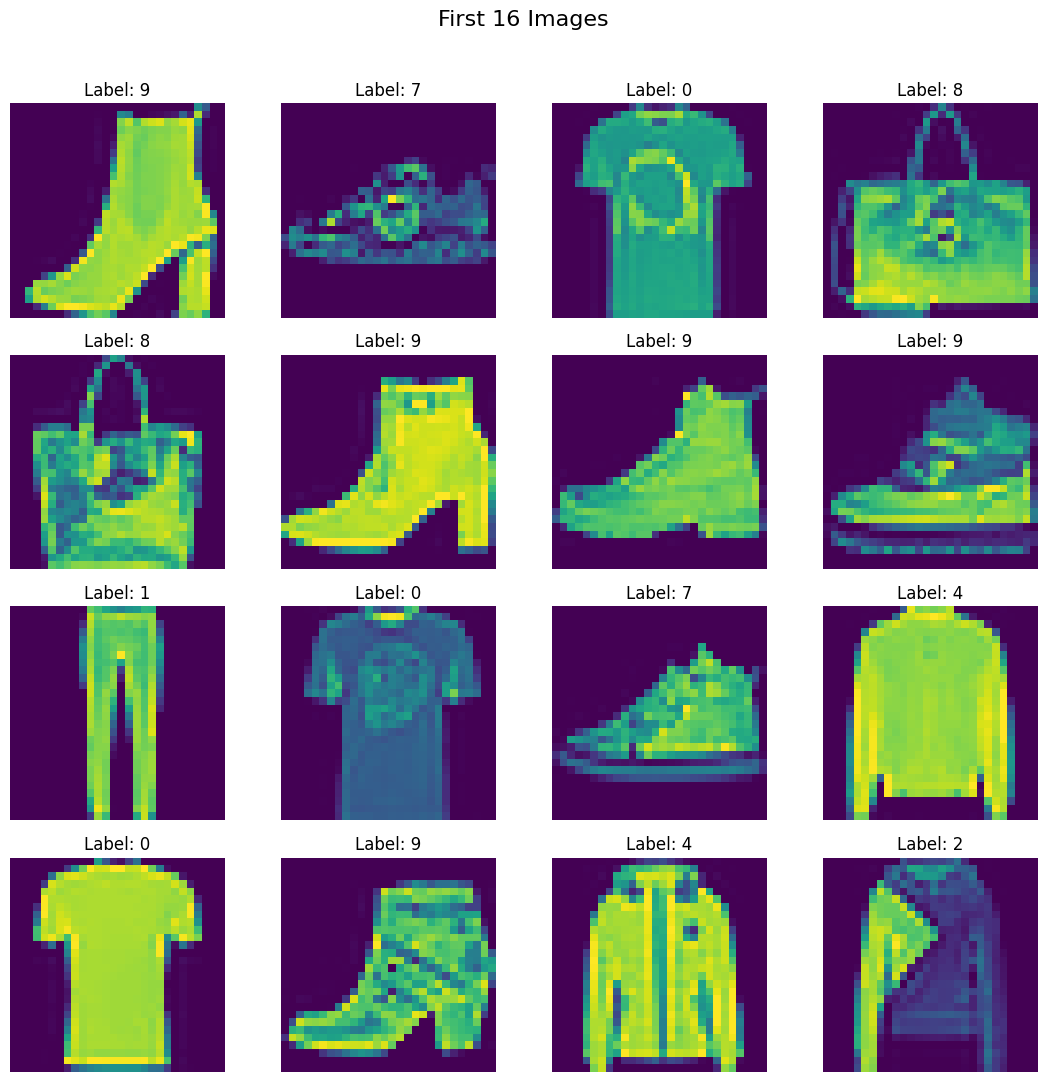

In [5]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(11, 11))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [6]:
device = torch.device('cuda' if torch.cuda.is_available()else 'cpu')
print(f'{device}')

cpu


In [9]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [10]:
x

array([[  0.,   0.,   0., ..., 165.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,  nan,  nan,  nan]])

In [13]:
y

array([9, 7, 0, ..., 0, 4, 4])

In [14]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=44)

In [15]:
x_train.shape

(3778, 784)

In [16]:
y_train.shape

(3778,)

In [19]:
# need to scale the feature in limit to 1
x_train = x_train/255.0
x_test = x_test/255.0

In [22]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [32]:
# creating custom dataset and loader
class customDataSet(Dataset):
  def __init__(self ,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx] , self.labels[idx]

In [37]:
train_DataSet = customDataSet(x_train,y_train)
test_DataSet = customDataSet(x_test,y_test)


In [ ]:
train_DataSet[0]

In [38]:
# dataloader
train_loader = DataLoader(train_DataSet , batch_size=32,shuffle=True)
test_loader = DataLoader(test_DataSet,batch_size=32,shuffle = True)

In [44]:
class MyNN(nn.Module):

  def __init__ (self, num_features):

    super().__init__()
    self.model = nn.Sequntial(
        nn.Linear(num_features,128),
        Relu(),
        nn.Linear(128,64),
        Relu(),
        nn.Linear(64,10)
    )
  def forward(self, x):

    return self.model(x)